# Single-Cell RNA-Sequencing Gene Expression Project

### Load Data

In [45]:
import os
import random

os.environ.setdefault("MPLCONFIGDIR", ".matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", ".cache")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.stats import poisson

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

SEED = 100
CELL_TYPES = ["astro_like", "endo_like", "microglia_like", "pyramidal_like"]

sns.set_theme(style="whitegrid", context="notebook")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()
zeisel = pd.read_csv('Zeisel.csv')
print(zeisel)

          Unnamed: 0          cell_type  Sema3c  Atp1b2  Prkar2b  Cxcl14  \
0     1772071015_C02       interneurons      11       9        5      22   
1     1772071017_G12       interneurons       0       5        1      18   
2     1772071017_A05       interneurons      25       8       14      26   
3     1772071014_B06       interneurons       1       6        5      93   
4     1772067065_H06       interneurons      10       7       21       0   
...              ...                ...     ...     ...      ...     ...   
3000  1772067059_B04  endothelial-mural       0       1        0       0   
3001  1772066097_D04  endothelial-mural       0       0        0       0   
3002  1772063068_D01  endothelial-mural       0       0        0       0   
3003  1772066098_A12  endothelial-mural       0       1        0       1   
3004  1772058148_F03  endothelial-mural       0       2        0       0   

      Rit2  Scg2  L2hgdh  Cited2  ...  Irak1  Lage3  G6pdx  Fundc2  Zmat1  \
0        2

## Preliminary Exploratory Data Analysis

In [2]:
counts = zeisel.iloc[:, 2:].to_numpy()
hidden_labels = zeisel.iloc[:, 1]
gene_names = zeisel.columns[2:]
print("counts shape:", counts.shape)
print("unique cell types:", pd.unique(hidden_labels).tolist())
print("fraction of zeros:", round((counts == 0).mean(), 3))

counts shape: (3005, 1000)
unique cell types: ['interneurons', 'pyramidal SS', 'pyramidal CA1', 'oligodendrocytes', 'microglia', 'endothelial-mural', 'astrocytes_ependymal']
fraction of zeros: 0.774


,quantity,value
0,cells,3005
1,genes,1000
2,median library size,729
3,median zero fraction,78.4%


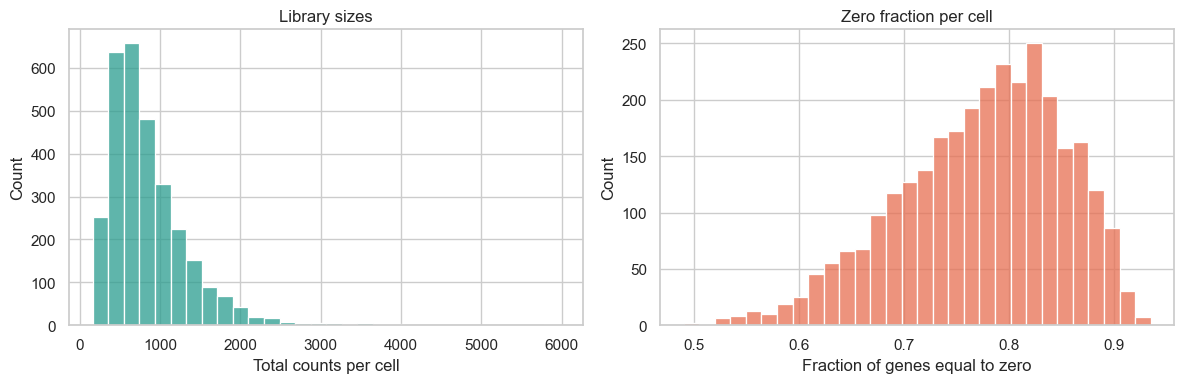

In [3]:
library_size = counts.sum(axis=1, keepdims=True)
cpm = counts / np.clip(library_size, 1, None) * 1.0e4
log_cpm = np.log1p(cpm).astype(np.float32)

summary = pd.DataFrame(
    {
        "quantity": [
            "cells",
            "genes",
            "median library size",
            "median zero fraction",
        ],
        "value": [
            counts.shape[0],
            counts.shape[1],
            int(np.median(library_size)),
            f"{np.median((counts == 0).mean(axis=1)):.1%}",
        ],
    }
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(library_size.ravel(), bins=30, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Library sizes")
axes[0].set_xlabel("Total counts per cell")

sns.histplot((counts == 0).mean(axis=1), bins=30, ax=axes[1], color="#E76F51")
axes[1].set_title("Zero fraction per cell")
axes[1].set_xlabel("Fraction of genes equal to zero")

plt.tight_layout()
plt.show()


## Dimension Reduction

### Top Ten Most-Variable Genes

In [4]:
def top_variable_genes(log_cpm, top_n):
    return np.argsort(log_cpm.var(axis=0))[-top_n:]


top_idx = top_variable_genes(log_cpm, top_n=80)
scaler = StandardScaler()
x = scaler.fit_transform(log_cpm[:, top_idx]).astype(np.float32)

print("input to PCA/VAE:", x.shape)
print("first 10 selected genes:", [gene_names[i] for i in top_idx[:10]])

input to PCA/VAE: (3005, 80)
first 10 selected genes: ['Ryr3', 'Acot13', 'Ddr1', 'Ube2b', 'Agrn', 'Nudt4', 'Evi2a.evi2b', 'Mfge8', 'Cacna1a', 'Sat1']


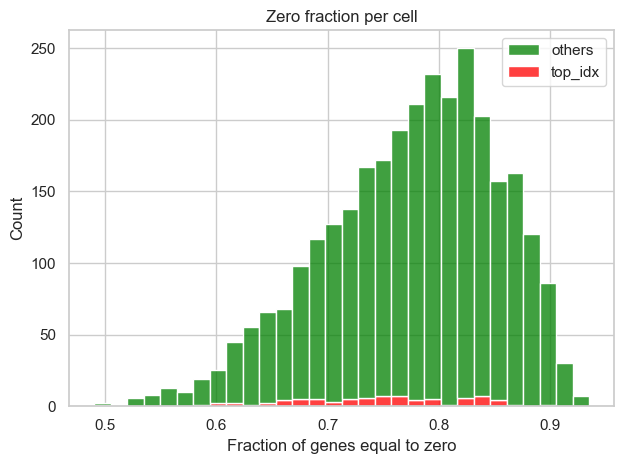

In [29]:
vals = (counts == 0).mean(axis=1)
mask = np.ones(len(vals), dtype=bool)
mask[top_idx] = False
fig, ax = plt.subplots()

# combine data
vals_combined = np.concatenate([vals[top_idx], vals[mask]])
labels = (["top_idx"] * len(vals[top_idx])) + (["others"] * len(vals[mask]))

sns.histplot(
    x=vals_combined,
    hue=labels,
    bins=30,
    multiple="stack",
    hue_order=["others", "top_idx"],
    palette={"top_idx": "red", "others": "green"},
    ax=ax
)

ax.set_title("Zero fraction per cell")
ax.set_xlabel("Fraction of genes equal to zero")

plt.tight_layout()
plt.show()

### Principal Component Analysis

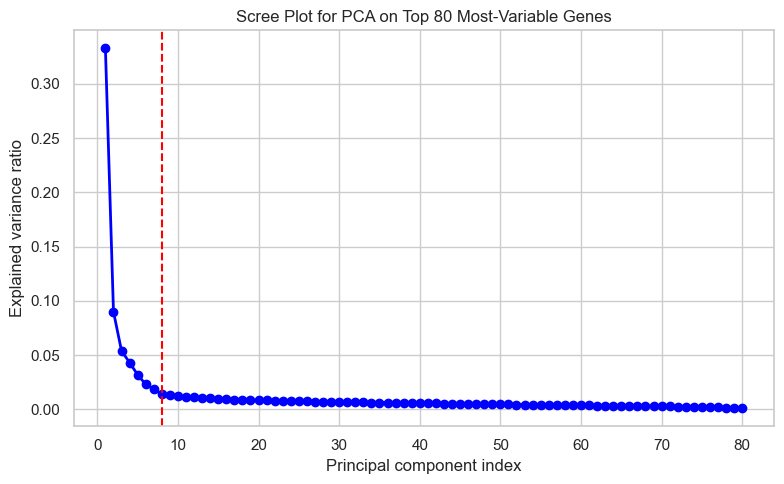

In [5]:
pca = PCA()
pca.fit(x)
exp_var_pca = pca.explained_variance_ratio_
PC_values = np.arange(pca.n_components_) + 1

# 3. Create the Scree Plot
plt.figure(figsize=(8, 5))
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.axvline(8, color='red', linestyle='--')
plt.title("Scree Plot for PCA on Top 80 Most-Variable Genes")
plt.tight_layout()
plt.show()

## K-Means

PCA + KMeans: ARI = 0.796, NMI = 0.748


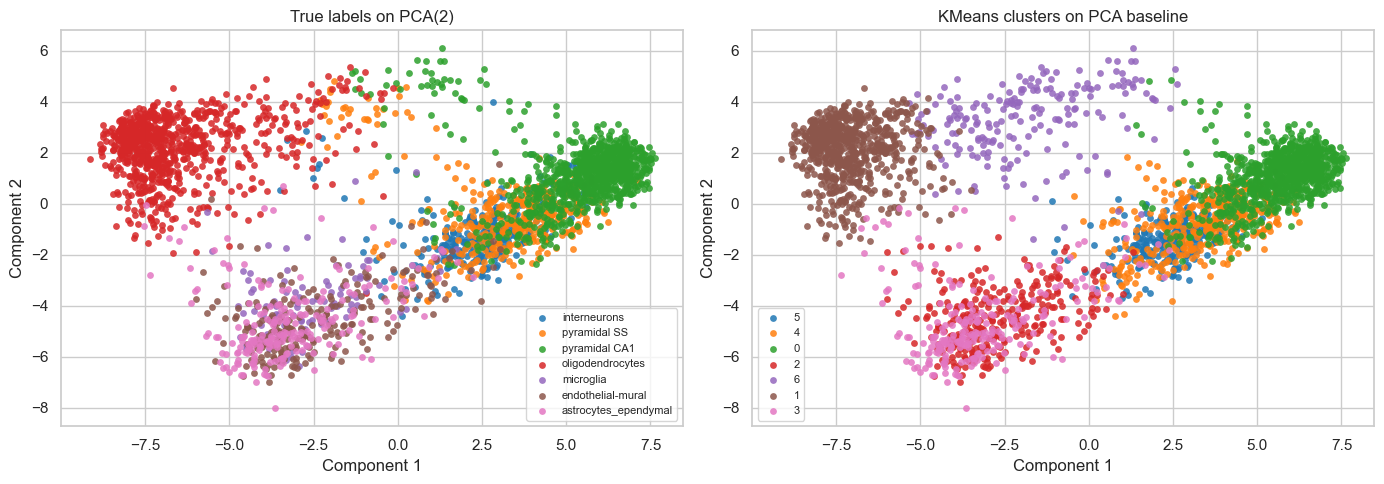

In [6]:
def plot_embedding(ax, coords, labels, title):
    labels = np.asarray(labels)
    order = pd.unique(labels)
    palette = sns.color_palette("tab10", n_colors=len(order))
    for label, color in zip(order, palette):
        mask = labels == label
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=24,
            alpha=0.85,
            color=[color],
            label=str(label),
            linewidths=0,
        )
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(loc="best", fontsize=8, frameon=True)


pca8 = PCA(n_components=5, random_state=SEED).fit_transform(x)
pca_kmeans = KMeans(n_clusters=7, n_init=50, random_state=SEED).fit_predict(pca8)

pca_ari = adjusted_rand_score(hidden_labels, pca_kmeans)
pca_nmi = normalized_mutual_info_score(hidden_labels, pca_kmeans)

print(f"PCA + KMeans: ARI = {pca_ari:.3f}, NMI = {pca_nmi:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_embedding(axes[0], pca8, hidden_labels, "True labels on PCA(2)")
plot_embedding(axes[1], pca8, pca_kmeans, "KMeans clusters on PCA baseline")
plt.tight_layout()
plt.show()

## Poisson Mixture Models

In [7]:
pois_x = counts[:, top_idx]
pois_x.shape

(3005, 80)

In [57]:
def multivariate_poisson_mixture_em(X, K, max_iter=100, tol=1e-6):
    N, D = X.shape
    
    pi = np.full(K, 1/K)
    lambdas = np.random.uniform(0.5, 1.5, (K, D)) * np.mean(X, axis=0)
    
    for i in range(max_iter):
        log_probs = np.zeros((N, K))
        for k in range(K):
            log_probs[:, k] = np.sum(poisson.logpmf(X, lambdas[k, :]), axis=1) + np.log(pi[k])
            
        log_max = np.max(log_probs, axis=1, keepdims=True)
        resp = np.exp(log_probs - log_max)
        resp /= np.sum(resp, axis=1, keepdims=True)
        
        Nk = np.sum(resp, axis=0)
        pi_new = Nk / N
        lambdas_new = (resp.T @ X) / Nk[:, np.newaxis]
        
        if np.allclose(lambdas, lambdas_new, atol=tol):
            break
            
        pi, lambdas = pi_new, lambdas_new
        
    return pi, lambdas, resp

In [58]:
fitted_lambdas, fitted_pi, responsibilities = multivariate_poisson_mixture_em(pois_x, K=7, max_iter=100, tol=1e-6)
clusters = np.argmax(responsibilities, axis=1)

In [59]:
pmm_ari = adjusted_rand_score(hidden_labels, clusters)
pmm_nmi = normalized_mutual_info_score(hidden_labels, clusters)
print(f"GMM: ARI = {pmm_ari:.3f}, NMI = {pmm_nmi:.3f}")

GMM: ARI = 0.610, NMI = 0.651


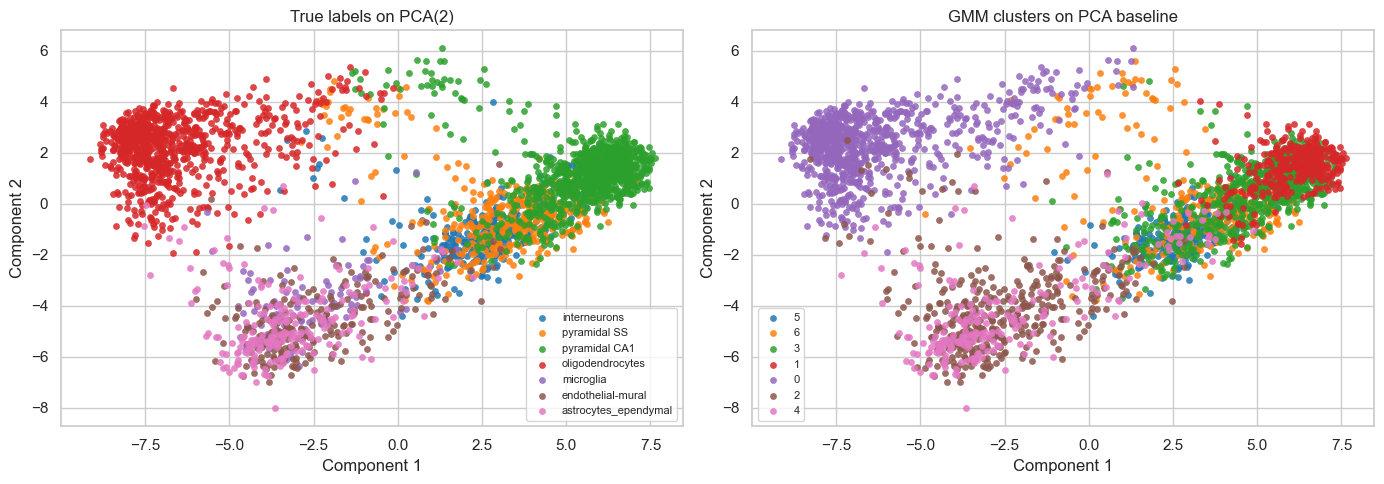

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_embedding(axes[0], pca8, hidden_labels, "True labels on PCA(2)")
plot_embedding(axes[1], pca8, clusters, "GMM clusters on PCA baseline")
plt.tight_layout()
plt.show()

## Variational Autoencoders

In [ ]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 64], latent_dim=2, activation=nn.ReLU):
        super().__init__()

        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(activation())
            prev_dim = h_dim

        self.encoder = nn.Sequential(*encoder_layers)

        self.mu = nn.Linear(prev_dim, latent_dim)
        self.logvar = nn.Linear(prev_dim, latent_dim)

        # Decoder (reverse hidden dims)
        decoder_layers = []
        prev_dim = latent_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(activation())
            prev_dim = h_dim

        decoder_layers.append(nn.Linear(prev_dim, input_dim))

        self.decoder = nn.Sequential(*decoder_layers)

In [ ]:
# Define the VAE training function with configurable architecture and training hyperparameters
def train_vae(x, activation, hidden_dim=64, latent_dim=2, beta=0.01, epochs=80, batch_size=64):
    set_seed()                                                        # Fix random seeds for reproducibility across runs
    x_tensor = torch.tensor(x, dtype=torch.float32)                  # Convert numpy array to a float32 PyTorch tensor
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=True)  # Wrap data in a DataLoader for mini-batch iteration with shuffling each epoch

    model = VariationalAutoencoder(
        input_dim=x_tensor.shape[1],   # Set input size to number of features in the dataset
        activation = activation,
        hidden_dim=hidden_dim,          # Pass hidden layer size to the model
        latent_dim=latent_dim,          # Pass latent space dimensions to the model
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Use Adam optimizer with learning rate 0.001 to update model weights
    history = []                                                # Initialize empty list to track per-epoch metrics

    for epoch in range(1, epochs + 1):  # Loop over each training epoch (1-indexed)
        losses = []        # Reset batch loss accumulator at the start of each epoch
        recon_losses = []  # Reset reconstruction loss accumulator
        kl_losses = []     # Reset KL divergence loss accumulator

        for (batch,) in loader:                              # Iterate over mini-batches from the DataLoader
            optimizer.zero_grad()                            # Clear gradients from the previous step to prevent accumulation
            recon, mu, logvar = model(batch)                 # Forward pass: get reconstruction, latent mean, and log-variance
            recon_loss = F.mse_loss(recon, batch)            # Compute reconstruction loss: MSE between input and its reconstruction
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence: measures how far the latent distribution is from standard normal N(0,1)
            loss = recon_loss + beta * kl_loss               # Total loss: reconstruction + β-weighted KL (β controls the tradeoff)
            loss.backward()                                  # Backpropagate gradients through the entire model
            optimizer.step()                                 # Update model weights using the computed gradients

            losses.append(loss.item())             # Record scalar total loss for this batch
            recon_losses.append(recon_loss.item()) # Record scalar reconstruction loss for this batch
            kl_losses.append(kl_loss.item())       # Record scalar KL loss for this batch

        history.append(
            {
                "epoch": epoch,                          # Store epoch number
                "loss": float(np.mean(losses)),          # Average total loss across all batches this epoch
                "recon_loss": float(np.mean(recon_losses)),  # Average reconstruction loss this epoch
                "kl_loss": float(np.mean(kl_losses)),    # Average KL loss this epoch
            }
        )

    with torch.no_grad():                              # Disable gradient tracking (inference only, saves memory)
        latent_mean, _ = model.encode(x_tensor)        # Encode full dataset to get latent means μ (discard log-variance)

    return model, latent_mean.numpy(), pd.DataFrame(history)  # Return trained model, numpy latent means, and history as a DataFrame


### VAE: 1 Hidden Layer w/ ReLU

In [40]:
# Train the VAE on x with specified hyperparameters and unpack the three return values
vae, latent_mean, history = train_vae(x, activation = nn.ReLU, hidden_dim=64, latent_dim=2, beta=0.01, epochs=80)
# Cluster the 2D latent means into 4 clusters using KMeans with 50 random initialisations for stability
vae_kmeans = KMeans(n_clusters=7, n_init=50, random_state=SEED).fit_predict(latent_mean)

vae1_ari = adjusted_rand_score(hidden_labels, vae_kmeans)          # Compute ARI: measures cluster-to-true-label agreement (1.0 = perfect)
vae1_nmi = normalized_mutual_info_score(hidden_labels, vae_kmeans) # Compute NMI: measures shared information between clusters and true labels (1.0 = perfect)

print(f"VAE + KMeans: ARI = {vae1_ari:.3f}, NMI = {vae1_nmi:.3f}") # Print both metrics rounded to 3 decimal places
history.tail()  # Display the last 5 rows of training history to inspect convergence

VAE + KMeans: ARI = 0.751, NMI = 0.725


,epoch,loss,recon_loss,kl_loss
75,76,0.507165,0.481051,2.611396
76,77,0.506165,0.480250,2.591516
77,78,0.506174,0.480296,2.587801
78,79,0.505883,0.480108,2.577522
79,80,0.505500,0.479778,2.572217


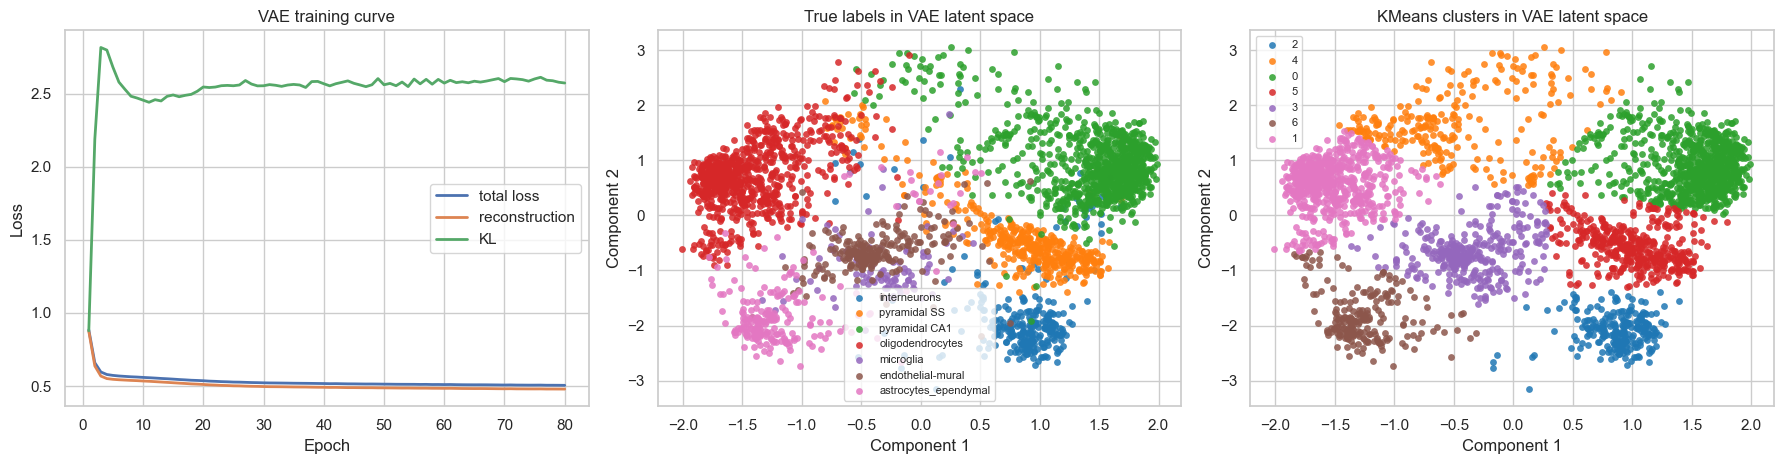

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(history["epoch"], history["loss"], label="total loss", lw=2)
axes[0].plot(history["epoch"], history["recon_loss"], label="reconstruction", lw=2)
axes[0].plot(history["epoch"], history["kl_loss"], label="KL", lw=2)
axes[0].set_title("VAE training curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

plot_embedding(axes[1], latent_mean, hidden_labels, "True labels in VAE latent space")
plot_embedding(axes[2], latent_mean, vae_kmeans, "KMeans clusters in VAE latent space")

plt.tight_layout()
plt.show()

### VAE: 1 Hidden Layer w/ Sigmoid

In [36]:
# Train the VAE on x with specified hyperparameters and unpack the three return values
vae, latent_mean, history = train_vae(x, activation = nn.Sigmoid, hidden_dim=64, latent_dim=2, beta=0.01, epochs=80)
# Cluster the 2D latent means into 4 clusters using KMeans with 50 random initialisations for stability
vae_kmeans = KMeans(n_clusters=7, n_init=50, random_state=SEED).fit_predict(latent_mean)

vae2_ari = adjusted_rand_score(hidden_labels, vae_kmeans)          # Compute ARI: measures cluster-to-true-label agreement (1.0 = perfect)
vae2_nmi = normalized_mutual_info_score(hidden_labels, vae_kmeans) # Compute NMI: measures shared information between clusters and true labels (1.0 = perfect)

print(f"VAE + KMeans: ARI = {vae2_ari:.3f}, NMI = {vae2_nmi:.3f}") # Print both metrics rounded to 3 decimal places
history.tail()  # Display the last 5 rows of training history to inspect convergence

VAE + KMeans: ARI = 0.694, NMI = 0.667


,epoch,loss,recon_loss,kl_loss
75,76,0.540881,0.516330,2.455077
76,77,0.539994,0.515570,2.442402
77,78,0.539623,0.515167,2.445666
78,79,0.539154,0.514606,2.454788
79,80,0.538335,0.514080,2.425489


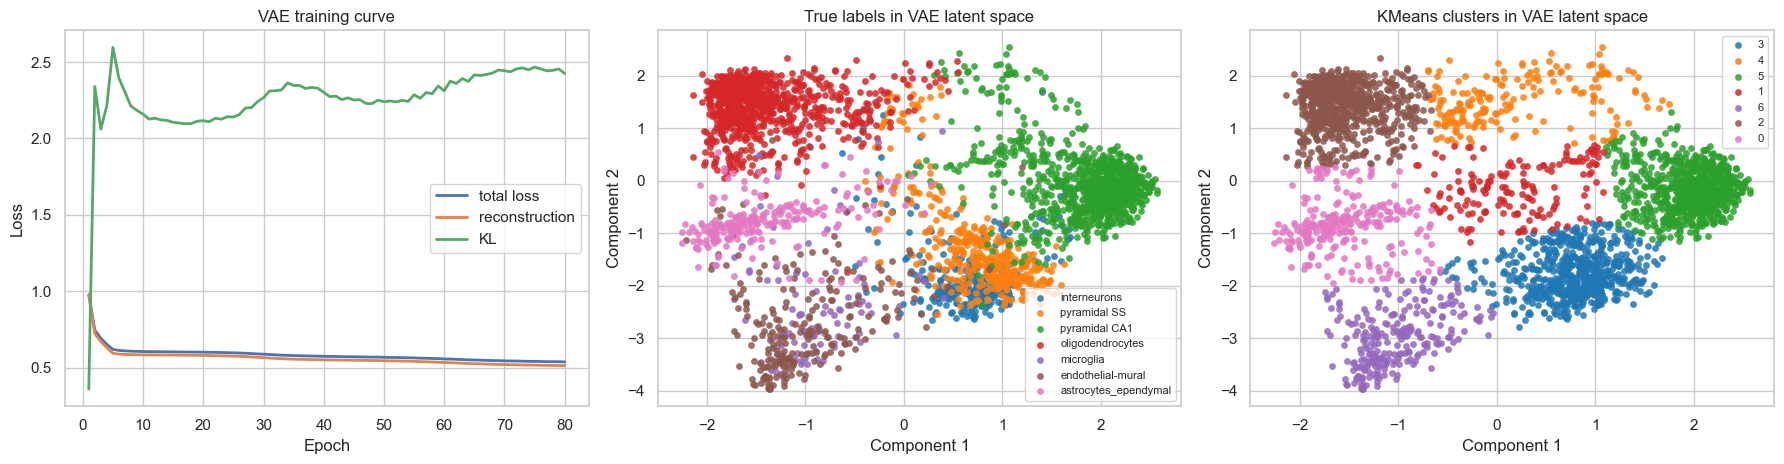

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(history["epoch"], history["loss"], label="total loss", lw=2)
axes[0].plot(history["epoch"], history["recon_loss"], label="reconstruction", lw=2)
axes[0].plot(history["epoch"], history["kl_loss"], label="KL", lw=2)
axes[0].set_title("VAE training curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

plot_embedding(axes[1], latent_mean, hidden_labels, "True labels in VAE latent space")
plot_embedding(axes[2], latent_mean, vae_kmeans, "KMeans clusters in VAE latent space")

plt.tight_layout()
plt.show()

## Comparison

In [ ]:
comparison = pd.DataFrame(
    [
        {
            "representation": "PCA(5) + KMeans",
            "ARI": pca_ari,
            "NMI": pca_nmi,
        },
        {
            "representation": "Poisson Gaussian mdeol",
            "ARI": pmm_ari,
            "NMI": pmm_nmi,
        },
        {
            "representation": "2D VAE latent mean (ReLU) + KMeans",
            "ARI": vae1_ari,
            "NMI": vae1_nmi,
        },
        {
            "representation": "2D VAE latent mean (Sigmoid) + KMeans",
            "ARI": vae2_ari,
            "NMI": vae2_nmi,
        },
    ]
).round(3)

comparison

,representation,ARI,NMI
0,PCA(5) + KMeans,0.796,0.748
1,Poisson Gaussian mdeol,0.517,0.534
2,2D VAE latent mean (ReLU) + KMeans,0.751,0.725
3,2D VAE latent mean (Sigmoid) + KMeans,0.694,0.667


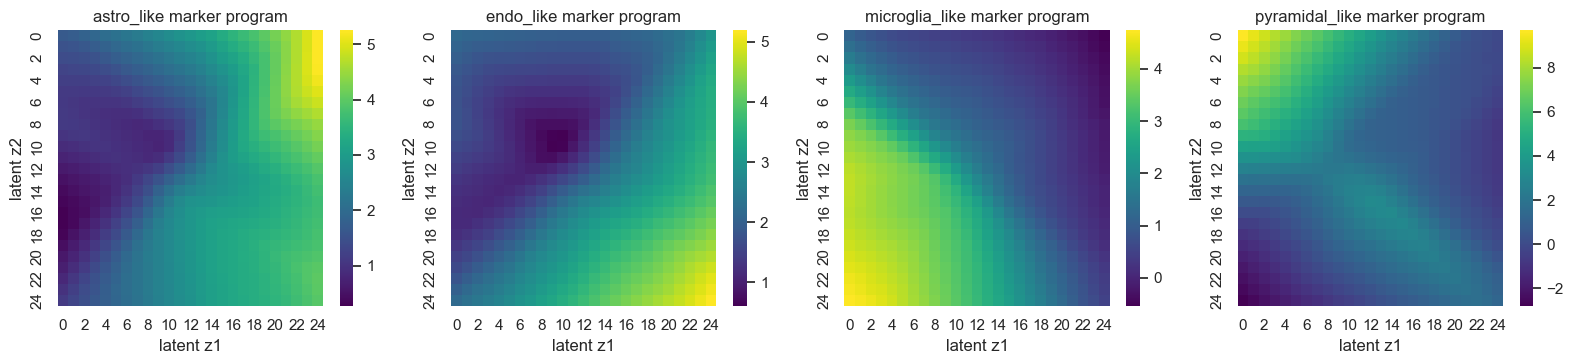

In [15]:
def plot_marker_landscapes(model, scaler, selected_gene_idx, marker_blocks, names):
    with torch.no_grad():
        z = latent_mean
        grid_x = np.linspace(z[:, 0].min() - 0.5, z[:, 0].max() + 0.5, 25)
        grid_y = np.linspace(z[:, 1].min() - 0.5, z[:, 1].max() + 0.5, 25)
        xx, yy = np.meshgrid(grid_x, grid_y)
        latent_grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

        decoded_std = model.decoder(torch.tensor(latent_grid)).numpy()
        decoded_log_cpm = scaler.inverse_transform(decoded_std)

    fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3.8))
    for ax, name, block in zip(axes, names, marker_blocks):
        mask = np.isin(selected_gene_idx, block)
        score = decoded_log_cpm[:, mask].mean(axis=1).reshape(xx.shape)
        sns.heatmap(score, cmap="viridis", ax=ax, cbar=True)
        ax.set_title(f"{name} marker program")
        ax.set_xlabel("latent z1")
        ax.set_ylabel("latent z2")

    plt.tight_layout()
    plt.show()

n_types = len(pd.unique(hidden_labels))
n_genes = len(pd.unique(gene_names))
marker_blocks = np.array_split(np.arange(n_genes), n_types)


plot_marker_landscapes(
    model=vae,
    scaler=scaler,
    selected_gene_idx=top_idx,
    marker_blocks=marker_blocks,
    names=CELL_TYPES,
)